这里说频率是指一个机场航班出现的频率

## 加载数据

数据已经预处理过了

In [1]:
import pandas as pd

# 加载数据
data = pd.read_csv('../../data-hh/my/hh_result/result_all.csv', dtype={'aircraft': str})

# 查看前几行数据，确保加载成功
print(data.head())

print(data.info())

         flt_no bd_type    cap aircraft  legs  leg_no  duration  pax  \
0  KgJrsp7Jd78=      窄体  132.0      319     1       1      1.07   25   
1  P9IRwar34h0=      窄体  189.0      321     1       1      1.38  151   
2  mJitm0UDfM4=      窄体  132.0      319     1       1      1.57   38   
3  jXr97M1wpn4=      窄体  132.0      319     1       1      1.58  109   
4  izjfHOxAho4=      窄体  132.0      319     1       1      1.80  124   

              a             b  ...  year  month  day  weekday  hour  minute  \
0  KNqX4/Q5Noc=  HexFWXqbb8I=  ...  2023     10    1        6    12      15   
1  AKQNtuL5r6Q=  Mv6HkAiSLUk=  ...  2023     10    1        6    20      10   
2  n465JzB8Rrw=  N4hmDZN/CJQ=  ...  2023     10    1        6    16      45   
3  N4hmDZN/CJQ=  n465JzB8Rrw=  ...  2023     10    1        6    19      40   
4  5t+HPO9Mu/w=  X5e5r3CS4OA=  ...  2023     10    1        6    13       5   

   second          from            to   unit_price  
0       0  KNqX4/Q5Noc=  HexFWXqbb8I=  

## 编码分类变量

### 新增城市标签

In [2]:
# 加载字典
with open('../../data-hh/my/encoder/city_labels_总客流加权图标签.json', 'r') as file:
    city_labels_loaded = json.load(file)

print("加载的字典：", city_labels_loaded)

加载的字典： {'KNqX4/Q5Noc=': 1, 'HexFWXqbb8I=': 1, 'AKQNtuL5r6Q=': 1, 'Mv6HkAiSLUk=': 1, 'n465JzB8Rrw=': 1, 'N4hmDZN/CJQ=': 1, '5t+HPO9Mu/w=': 0, 'X5e5r3CS4OA=': 1, 'EF9aodHSh3E=': 1, 'iX2Pe2pxiqQ=': 0, 'lrbLyY7nRiw=': 1, 'vbo2dwBOeps=': 1, 'fl/vmiIcdls=': 1, 'a2cXIUGpIbw=': 1, 'Ne7JZ9C2ayc=': 1, 'XUXDuFGVfBM=': 2, 'tKjndGSl9NQ=': 1, 'xIqe+QQIQXQ=': 1, 'RTA+2OkM90I=': 1, 'KETr2NAmAHE=': 1, 'OJ0BsQ7KlKk=': 1, 'So/c8CkA/Xs=': 1, 'Lue5PP9SfQU=': 1, 'h9GisD/ZayE=': 1, 'zwVGiYamVc0=': 1, '/qxKZMQeBus=': 1, 'DUbxF00Y8a0=': 1, 'Y50ETJ8qYSE=': 1, 'QyEgIt0M8Sg=': 1, 'xRL77yJN1tk=': 1, 'hwin1ipuzwk=': 1, 'CnmNtb5MOJA=': 1, '9j4ofoSZvc4=': 1, 'Qe7TEMbQt6o=': 1, 'tiwC3iWlaiU=': 0, 'g1hKMyP1V8I=': 1, '/M8gHzjxpNU=': 1, 'wSF4qXvI044=': 1, 'grkgazDvJmY=': 1, 'AfKac4FzdXs=': 1, 'yypkiQCX5lk=': 1, 'qjPVpekqsPo=': 1, 'FWD6O2fHsIU=': 1, '4Liydpz6+ug=': 1, '1/9nd1jNCE0=': 1, '4jcxTvZ+J1A=': 1, 'y+pJ91YLvhA=': 1, '2WRfpdopfDw=': 1, '81MA7ppp7mI=': 1, 'gK3uAaRHrOs=': 1, 'KFsTKxkC/6g=': 1, 'XuLAnICDnIM=': 1, '+O1

In [3]:
# 使用 map 对 'a', 'b', 'c', 'from', 'to' 列进行标签化，新增对应的标签列
data['a_label'] = data['a'].map(city_labels_loaded)
data['b_label'] = data['b'].map(city_labels_loaded)
data['c_label'] = data['c'].map(city_labels_loaded)
data['from_label'] = data['from'].map(city_labels_loaded)
data['to_label'] = data['to'].map(city_labels_loaded)

### 新增城市二维嵌入

In [4]:
import json

# 加载字典
with open('../../data-hh/my/encoder/城市嵌入编码_总客流加权图', 'r') as file:
    city_embeddings = json.load(file)

print("加载的字典：", city_embeddings)


加载的字典： {'KNqX4/Q5Noc=': [-0.30124732851982117, -0.29528331756591797], 'HexFWXqbb8I=': [0.6225460767745972, -0.0579943023622036], 'AKQNtuL5r6Q=': [-0.21069030463695526, -1.019451379776001], 'Mv6HkAiSLUk=': [-0.3282053470611572, -0.3431733250617981], 'n465JzB8Rrw=': [0.5361536145210266, -0.13385199010372162], 'N4hmDZN/CJQ=': [0.01228764932602644, -1.0385137796401978], '5t+HPO9Mu/w=': [0.735469400882721, -0.7177906036376953], 'X5e5r3CS4OA=': [0.0628906860947609, -0.45157182216644287], 'EF9aodHSh3E=': [-0.3087059259414673, -0.7854071259498596], 'iX2Pe2pxiqQ=': [0.5242692232131958, -0.5245727896690369], 'lrbLyY7nRiw=': [-0.3287799656391144, -0.36911284923553467], 'vbo2dwBOeps=': [-0.44242605566978455, -0.8875601291656494], 'fl/vmiIcdls=': [-0.08861442655324936, -0.2671923339366913], 'a2cXIUGpIbw=': [-0.12381066381931305, -0.9250358939170837], 'Ne7JZ9C2ayc=': [0.026035215705633163, 0.03381938114762306], 'XUXDuFGVfBM=': [1.1213572025299072, -1.1232333183288574], 'tKjndGSl9NQ=': [-0.3204067349

In [5]:
import pandas as pd
import numpy as np

# 将 city_embeddings 转换为 DataFrame
embedding_df = pd.DataFrame.from_dict(city_embeddings, orient='index', columns=['embedding_1', 'embedding_2'])
embedding_df.index.name = 'city'

# 用 'a', 'b', 'c', 'from', 'to' 字段与 embedding_df 合并
data = data.merge(embedding_df, left_on='a', right_index=True, how='left')
data.rename(columns={'embedding_1': 'a_embedding_1', 'embedding_2': 'a_embedding_2'}, inplace=True)

data = data.merge(embedding_df, left_on='b', right_index=True, how='left')
data.rename(columns={'embedding_1': 'b_embedding_1', 'embedding_2': 'b_embedding_2'}, inplace=True)

data = data.merge(embedding_df, left_on='c', right_index=True, how='left')
data.rename(columns={'embedding_1': 'c_embedding_1', 'embedding_2': 'c_embedding_2'}, inplace=True)

data = data.merge(embedding_df, left_on='from', right_index=True, how='left')
data.rename(columns={'embedding_1': 'from_embedding_1', 'embedding_2': 'from_embedding_2'}, inplace=True)

data = data.merge(embedding_df, left_on='to', right_index=True, how='left')
data.rename(columns={'embedding_1': 'to_embedding_1', 'embedding_2': 'to_embedding_2'}, inplace=True)

# 查看添加的新列
print(data[['a_embedding_1', 'a_embedding_2', 'b_embedding_1', 'b_embedding_2', 'c_embedding_1', 'c_embedding_2', 'from_embedding_1', 'from_embedding_2', 'to_embedding_1', 'to_embedding_2']])


         a_embedding_1  a_embedding_2  b_embedding_1  b_embedding_2  \
0            -0.301247      -0.295283       0.622546      -0.057994   
1            -0.210690      -1.019451      -0.328205      -0.343173   
2             0.536154      -0.133852       0.012288      -1.038514   
3             0.012288      -1.038514       0.536154      -0.133852   
4             0.735469      -0.717791       0.062891      -0.451572   
...                ...            ...            ...            ...   
5999220      -0.425696      -0.908476      -0.442426      -0.887560   
5999221      -0.442426      -0.887560      -0.425696      -0.908476   
5999222      -0.425696      -0.908476      -0.442426      -0.887560   
5999223      -0.442426      -0.887560      -0.327313       0.064449   
5999224      -0.327313       0.064449      -0.442426      -0.887560   

         c_embedding_1  c_embedding_2  from_embedding_1  from_embedding_2  \
0                  NaN            NaN         -0.301247         -0.295

### 统计不同城市的频率

In [6]:
# 将 from 和 to 两列合并，并统计每个城市的出现次数
city_count_series = pd.concat([data['from'], data['to']]).value_counts()

# 转换为 city_count 数据框
city_count = city_count_series.reset_index()
city_count.columns = ['city', 'count']

# 3. 创建 city_map，将每个城市映射为其出现次数（或者任何你需要的值）
city_map = dict(zip(city_count['city'], city_count['count']))

# 输出结果
print(city_count)

             city   count
0    vbo2dwBOeps=  478332
1    /M8gHzjxpNU=  450316
2    gK3uAaRHrOs=  446006
3    So/c8CkA/Xs=  418933
4    0J4jz5aCatU=  408305
..            ...     ...
247  iPk6Y04ZgnI=     122
248  MgrS1LT2KO4=      91
249  DwCmftDLjPw=      62
250  wbf1sxPhwNM=      60
251  Eed3EdkMDqg=      49

[252 rows x 2 columns]


使用 json 保存和加载 city_map

In [7]:
import json

# 保存 city_map 到 JSON 文件
with open('../../data-hh/my/encoder/city_map_频率编码.json', 'w') as f:
    json.dump(city_map, f)

print("city_map_频率编码 已保存到 city_map_频率编码")

city_map_频率编码 已保存到 city_map_频率编码


In [8]:
# 使用 city_map 替换指定列的值
columns_to_replace = ['a', 'b', 'c', 'from', 'to']

# 遍历指定列并直接用 map 映射
for col in columns_to_replace:
    data[col] = data[col].map(city_map)

# 输出结果
print(city_count)
print(data)

             city   count
0    vbo2dwBOeps=  478332
1    /M8gHzjxpNU=  450316
2    gK3uAaRHrOs=  446006
3    So/c8CkA/Xs=  418933
4    0J4jz5aCatU=  408305
..            ...     ...
247  iPk6Y04ZgnI=     122
248  MgrS1LT2KO4=      91
249  DwCmftDLjPw=      62
250  wbf1sxPhwNM=      60
251  Eed3EdkMDqg=      49

[252 rows x 2 columns]
               flt_no bd_type    cap aircraft  legs  leg_no  duration  pax  \
0        KgJrsp7Jd78=      窄体  132.0      319     1       1      1.07   25   
1        P9IRwar34h0=      窄体  189.0      321     1       1      1.38  151   
2        mJitm0UDfM4=      窄体  132.0      319     1       1      1.57   38   
3        jXr97M1wpn4=      窄体  132.0      319     1       1      1.58  109   
4        izjfHOxAho4=      窄体  132.0      319     1       1      1.80  124   
...               ...     ...    ...      ...   ...     ...       ...  ...   
5999220  BzUm4im0EqA=      窄体  152.0      320     1       1      3.03   99   
5999221  w+GXbx7u3EM=      窄体  152.0    

In [9]:
import joblib
from sklearn.preprocessing import LabelEncoder
import os

# 定义需要编码的分类特征
# categorical_columns = ['flt_no', 'bd_type', 'aircraft', 'a', 'b', 'c', 'from', 'to']
categorical_columns = ['flt_no', 'bd_type', 'aircraft']

# 创建并应用 LabelEncoder
label_encoders = {}

# 创建保存编码器的文件夹（如果文件夹不存在）
save_folder = '../../data-hh/my/encoder/'
os.makedirs(save_folder, exist_ok=True)  # 如果文件夹已存在，不会报错

# 遍历每个分类特征，使用 LabelEncoder 对其进行编码
for col in categorical_columns:
    le = LabelEncoder()  # 创建一个 LabelEncoder 实例
    data[col] = le.fit_transform(data[col])  # 对训练数据中的分类特征进行编码
    label_encoders[col] = le  # 将每个特征的编码器保存到字典中，方便后续使用

    # 保存每个编码器到指定文件夹
    encoder_path = os.path.join(save_folder, f"{col}_encoder_all.pkl")  # 构建保存路径
    joblib.dump(le, encoder_path)  # 使用 joblib 将编码器保存为 pkl 文件
    print(f"{col} 的编码器已保存为 {encoder_path}")  # 输出保存的路径

flt_no 的编码器已保存为 ../../data-hh/my/encoder/flt_no_encoder_all.pkl
bd_type 的编码器已保存为 ../../data-hh/my/encoder/bd_type_encoder_all.pkl
aircraft 的编码器已保存为 ../../data-hh/my/encoder/aircraft_encoder_all.pkl


## 特征和目标分离
我们要预测的是pax字段，其他字段作为特征。

In [10]:
# 特征列
# X = data[['flt_no', 'bd_type', 'cap', 'aircraft',  'leg_no', 'duration', 'a', 'b', 'c', 'year', 'month', 'day', 'weekday','holiday', 'hour', 'minute', 'second', 'from', 'to','unit_price']]
# X = data[['flt_no', 'bd_type', 'cap', 'aircraft', 'legs', 'leg_no', 'duration', 'a', 'b', 'c', 'year', 'month', 'day', 'weekday','hour', 'minute', 'second', 'from', 'to','unit_price']]
# X = data[['flt_no', 'bd_type', 'cap', 'aircraft', 'legs', 'leg_no', 'duration', 'a', 'b', 'c', 'year', 'month', 'day', 'weekday','hour', 'minute', 'second', 'from', 'to','unit_price','a_label' ,'b_label' ,'c_label' ,'from_label' ,'to_label']]

# 有abc，有标签，有嵌入
X = data[['flt_no', 'bd_type', 'cap', 'aircraft', 'legs', 'leg_no', 'duration', 'a', 'b', 'c', 'year', 'month', 'day', 'weekday','hour', 'minute', 'second', 'from', 'to','unit_price','a_label' ,'b_label' ,'c_label' ,'from_label' ,'to_label','a_embedding_1' , 'a_embedding_2' , 'b_embedding_1','b_embedding_2' , 'c_embedding_1' , 'c_embedding_2' , 'from_embedding_1','from_embedding_2' , 'to_embedding_1' , 'to_embedding_2']]

# 删除了abc，但有标签，有嵌入
# X = data[['flt_no', 'bd_type', 'cap', 'aircraft', 'legs', 'leg_no', 'duration', 'year', 'month', 'day', 'weekday','hour', 'minute', 'second', 'unit_price','a_label' ,'b_label' ,'c_label' ,'from_label' ,'to_label','a_embedding_1' , 'a_embedding_2' , 'b_embedding_1','b_embedding_2' , 'c_embedding_1' , 'c_embedding_2' , 'from_embedding_1','from_embedding_2' , 'to_embedding_1' , 'to_embedding_2']]

# 目标列
y = data['pax']

### 对x进行标准化

In [11]:
from sklearn.preprocessing import StandardScaler

# 对所有特征进行标准化
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# 将标准化后的数据转回 DataFrame 格式
X_scaled = pd.DataFrame(X_scaled, columns=X.columns)

# 查看结果
print(X_scaled.head())

     flt_no   bd_type       cap  aircraft      legs    leg_no  duration  \
0 -0.493562  0.292912 -1.099685 -1.323155 -0.759223 -0.514019 -1.281526   
1 -0.250050  0.292912  0.545039 -0.811678 -0.759223 -0.514019 -0.868947   
2  1.000435  0.292912 -1.099685 -1.323155 -0.759223 -0.514019 -0.616076   
3  0.856315  0.292912 -1.099685 -1.323155 -0.759223 -0.514019 -0.602767   
4  0.825566  0.292912 -1.099685 -1.323155 -0.759223 -0.514019 -0.309970   

          a         b   c  ...  a_embedding_1  a_embedding_2  b_embedding_1  \
0 -1.472534 -1.421227 NaN  ...      -0.055815       1.555359       2.246089   
1  0.099180 -1.342888 NaN  ...       0.149454      -0.676988      -0.170616   
2 -1.650126 -0.119802 NaN  ...       1.842354       2.052994       0.694879   
3 -0.318189 -1.414343 NaN  ...       0.654887      -0.735751       2.026489   
4 -1.233278 -1.260377 NaN  ...       2.294150       0.252923       0.823507   

   b_embedding_2  c_embedding_1  c_embedding_2  from_embedding_1  \
0     

### 对y进行标准化

In [12]:
# 对目标列 y 进行标准化
scaler_y = StandardScaler()
y_scaled = scaler_y.fit_transform(y.values.reshape(-1, 1))  # 将 y 转换为 2D 数组进行标准化

# 转换回 DataFrame 格式
y_scaled = pd.DataFrame(y_scaled, columns=['pax_scaled'])

# 查看标准化后的 y
print(y_scaled.head())

   pax_scaled
0   -1.941819
1    0.824975
2   -1.656357
3   -0.097290
4    0.232090


## 训练XGBoost模型

In [43]:
import xgboost as xgb
from sklearn.model_selection import train_test_split
from sklearn.metrics import mean_squared_error
import numpy as np

# 自定义 SMAPE 函数
def smape(y_true, y_pred):
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    diff = np.abs(y_true - y_pred)
    return np.mean(diff / denominator) * 100

# 自定义评估函数
def smape_eval(y_pred, dtrain):
    y_true = dtrain.get_label()
    smape_value = smape(y_true, y_pred)
    return 'SMAPE', smape_value

# 数据划分
X_train, X_temp, y_train, y_temp = train_test_split(X_scaled, y_scaled, test_size=0.2, random_state=42)
X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.5, random_state=42)

# 输出数据集大小
print(f'训练集大小: {X_train.shape[0]}')
print(f'验证集大小: {X_val.shape[0]}')
print(f'测试集大小: {X_test.shape[0]}')

# 转换为 DMatrix 格式
dtrain = xgb.DMatrix(X_train, label=y_train)
dval = xgb.DMatrix(X_val, label=y_val)
dtest = xgb.DMatrix(X_test, label=y_test)

# 设置参数
params = {
    'objective': 'reg:squarederror',
    'learning_rate': 0.2,
    'max_depth': 10,
    'subsample': 0.8,
    'colsample_bytree': 0.7,
    'alpha': 1,
    "lambda":1
}

# 设置评估集
evals = [(dtrain, 'train'), (dval, 'validation')]

# 训练模型，使用自定义评估指标
model = xgb.train(
    params,
    dtrain,
    num_boost_round=10000,
    evals=evals,
    early_stopping_rounds=10,
    custom_metric=smape_eval,  # 使用 custom_metric 参数
    verbose_eval=10 #隔多少轮显示一次
)

# 预测测试集
y_pred = model.predict(dtest)

# # 测试集 SMAPE 评估
# test_smape = smape(y_test, y_pred)
# print(f'SMAPE on Test Set: {test_smape:.2f}%')

# # 测试集 MSE 评估
# mse = mean_squared_error(y_test, y_pred)
# print(f'Mean Squared Error on Test Set: {mse}')


训练集大小: 4799380
验证集大小: 599922
测试集大小: 599923
[0]	train-rmse:0.87850	train-SMAPE:152.86936	validation-rmse:0.87916	validation-SMAPE:152.96225
[10]	train-rmse:0.57112	train-SMAPE:89.72875	validation-rmse:0.57307	validation-SMAPE:89.82210
[20]	train-rmse:0.53455	train-SMAPE:84.06165	validation-rmse:0.53769	validation-SMAPE:84.22777
[30]	train-rmse:0.51810	train-SMAPE:81.81430	validation-rmse:0.52244	validation-SMAPE:82.07118
[40]	train-rmse:0.50672	train-SMAPE:80.32138	validation-rmse:0.51189	validation-SMAPE:80.63205
[50]	train-rmse:0.49876	train-SMAPE:79.24182	validation-rmse:0.50481	validation-SMAPE:79.62145
[60]	train-rmse:0.49212	train-SMAPE:78.33337	validation-rmse:0.49886	validation-SMAPE:78.76809
[70]	train-rmse:0.48546	train-SMAPE:77.41757	validation-rmse:0.49300	validation-SMAPE:77.93485
[80]	train-rmse:0.48102	train-SMAPE:76.84506	validation-rmse:0.48923	validation-SMAPE:77.41502
[90]	train-rmse:0.47680	train-SMAPE:76.26333	validation-rmse:0.48564	validation-SMAPE:76.90296
[100]	

[850]	train-rmse:0.37582	train-SMAPE:63.57604	validation-rmse:0.42333	validation-SMAPE:68.06923
[860]	train-rmse:0.37515	train-SMAPE:63.49319	validation-rmse:0.42305	validation-SMAPE:68.03597
[870]	train-rmse:0.37450	train-SMAPE:63.41777	validation-rmse:0.42280	validation-SMAPE:67.99726
[880]	train-rmse:0.37386	train-SMAPE:63.33998	validation-rmse:0.42256	validation-SMAPE:67.96618
[890]	train-rmse:0.37322	train-SMAPE:63.25254	validation-rmse:0.42233	validation-SMAPE:67.92620
[900]	train-rmse:0.37253	train-SMAPE:63.16237	validation-rmse:0.42207	validation-SMAPE:67.89862
[910]	train-rmse:0.37193	train-SMAPE:63.09221	validation-rmse:0.42192	validation-SMAPE:67.87190
[920]	train-rmse:0.37129	train-SMAPE:63.01309	validation-rmse:0.42169	validation-SMAPE:67.83125
[930]	train-rmse:0.37075	train-SMAPE:62.94163	validation-rmse:0.42153	validation-SMAPE:67.81232
[940]	train-rmse:0.37020	train-SMAPE:62.87125	validation-rmse:0.42134	validation-SMAPE:67.77951
[950]	train-rmse:0.36957	train-SMAPE:62.

[1700]	train-rmse:0.33398	train-SMAPE:58.31963	validation-rmse:0.41294	validation-SMAPE:66.44564
[1710]	train-rmse:0.33361	train-SMAPE:58.27106	validation-rmse:0.41286	validation-SMAPE:66.43739
[1720]	train-rmse:0.33316	train-SMAPE:58.21088	validation-rmse:0.41274	validation-SMAPE:66.41701
[1730]	train-rmse:0.33275	train-SMAPE:58.15811	validation-rmse:0.41266	validation-SMAPE:66.40266
[1740]	train-rmse:0.33240	train-SMAPE:58.10869	validation-rmse:0.41262	validation-SMAPE:66.39422
[1750]	train-rmse:0.33202	train-SMAPE:58.05780	validation-rmse:0.41258	validation-SMAPE:66.38625
[1760]	train-rmse:0.33166	train-SMAPE:58.01133	validation-rmse:0.41251	validation-SMAPE:66.37474
[1770]	train-rmse:0.33131	train-SMAPE:57.96854	validation-rmse:0.41247	validation-SMAPE:66.37084
[1780]	train-rmse:0.33096	train-SMAPE:57.92493	validation-rmse:0.41242	validation-SMAPE:66.36166
[1790]	train-rmse:0.33056	train-SMAPE:57.87689	validation-rmse:0.41237	validation-SMAPE:66.34493
[1800]	train-rmse:0.33019	trai

In [44]:
y_pred

array([-0.5841547,  2.346167 ,  0.7398454, ..., -1.4772576, -1.3980376,
        1.3055516], dtype=float32)

In [45]:
# 反标准化 y_test
y_test_original = scaler_y.inverse_transform(y_test.values.reshape(-1, 1))

# 反标准化预测结果 y_pred
y_pred_original = scaler_y.inverse_transform(y_pred.reshape(-1, 1))

In [46]:
y_test_original



array([[ 91.],
       [255.],
       [163.],
       ...,
       [ 35.],
       [ 29.],
       [173.]])

In [47]:
y_pred_original

array([[ 86.82814 ],
       [220.27519 ],
       [147.1232  ],
       ...,
       [ 46.156178],
       [ 49.763863],
       [172.8855  ]], dtype=float32)

In [48]:
# 正确的写法
test_results = list(zip(y_test_original[:100], y_pred_original[:100]))  # 真实值和预测值

print("\n20条测试结果（真实值 vs 预测值）:")
for i, (true_value, pred_value) in enumerate(test_results[:40]):
    # 如果是多维数组，使用 .item() 转换为标量
    true_value = true_value.item() if isinstance(true_value, np.ndarray) else true_value
    pred_value = pred_value.item() if isinstance(pred_value, np.ndarray) else pred_value
    print(f"第{i+1}条: 真实值={true_value}, 预测值={pred_value:.2f}")



20条测试结果（真实值 vs 预测值）:
第1条: 真实值=91.0, 预测值=86.83
第2条: 真实值=255.0, 预测值=220.28
第3条: 真实值=163.0, 预测值=147.12
第4条: 真实值=234.0, 预测值=229.84
第5条: 真实值=82.0, 预测值=109.79
第6条: 真实值=88.0, 预测值=95.78
第7条: 真实值=66.0, 预测值=74.50
第8条: 真实值=224.0, 预测值=197.17
第9条: 真实值=181.0, 预测值=174.03
第10条: 真实值=131.0, 预测值=126.25
第11条: 真实值=116.0, 预测值=124.25
第12条: 真实值=99.0, 预测值=131.63
第13条: 真实值=127.0, 预测值=116.47
第14条: 真实值=30.0, 预测值=47.91
第15条: 真实值=106.0, 预测值=102.94
第16条: 真实值=155.0, 预测值=138.78
第17条: 真实值=139.0, 预测值=141.62
第18条: 真实值=28.0, 预测值=42.86
第19条: 真实值=88.0, 预测值=116.02
第20条: 真实值=200.0, 预测值=179.31
第21条: 真实值=102.0, 预测值=129.58
第22条: 真实值=93.0, 预测值=91.78
第23条: 真实值=118.0, 预测值=151.31
第24条: 真实值=182.0, 预测值=171.90
第25条: 真实值=69.0, 预测值=105.57
第26条: 真实值=49.0, 预测值=62.52
第27条: 真实值=70.0, 预测值=66.42
第28条: 真实值=146.0, 预测值=126.03
第29条: 真实值=31.0, 预测值=30.15
第30条: 真实值=179.0, 预测值=156.86
第31条: 真实值=168.0, 预测值=156.65
第32条: 真实值=174.0, 预测值=186.13
第33条: 真实值=124.0, 预测值=116.07
第34条: 真实值=96.0, 预测值=105.41
第35条: 真实值=132.0, 预测值=139.62
第36条: 真实值=162.0, 预测值=148.39
第3

In [49]:
import numpy as np
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

def calculate_smape(y_true, y_pred):
    """
    计算 Symmetric Mean Absolute Percentage Error (SMAPE)
    """
    y_true, y_pred = np.array(y_true).ravel(), np.array(y_pred).ravel()
    denominator = (np.abs(y_true) + np.abs(y_pred)) / 2.0
    diff = np.abs(y_pred - y_true)
    
    # 避免除以零，将分母中为零的项替换为一个小值
    denominator = np.where(denominator == 0, 1e-8, denominator)
    
    smape = 100 * np.mean(diff / denominator)
    return smape


def calculate_mape(y_true, y_pred):
    """
    计算 Mean Absolute Percentage Error (MAPE)
    """
    y_true, y_pred = np.array(y_true).ravel(), np.array(y_pred).ravel()
    
    # 避免除以零，将 y_true 中的零值替换为一个小值
    y_true = np.where(y_true == 0, 1e-8, y_true)
    
    mape = 100 * np.mean(np.abs((y_true - y_pred) / y_true))
    return mape


# 假设 y_test 和 y_pred 已经是标准化反归一化后的数据
# 将其转换为一维数组以确保形状一致
y_test = np.array(y_test_original).ravel()
y_pred = np.array(y_pred_original).ravel()

# 评估指标
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = calculate_mape(y_test, y_pred)
smape = calculate_smape(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

# 打印结果
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'Mean Absolute Percentage Error (MAPE): {mape:.4f}%')
print(f'Symmetric Mean Absolute Percentage Error (SMAPE): {smape:.4f}%')
print(f'R-squared (R²): {r2:.4f}')


Mean Squared Error (MSE): 349.9147
Root Mean Squared Error (RMSE): 18.7060
Mean Absolute Error (MAE): 14.1517
Mean Absolute Percentage Error (MAPE): 16.4081%
Symmetric Mean Absolute Percentage Error (SMAPE): 14.8803%
R-squared (R²): 0.8311


似乎对于较小值预测存在误差

In [41]:
def calculate_smape(y_true, y_pred):
    """
    计算 Symmetric Mean Absolute Percentage Error (SMAPE)
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    smape = 100 * np.mean(2 * np.abs(y_pred - y_true) / (np.abs(y_true) + np.abs(y_pred)))
    return smape

def calculate_mape(y_true, y_pred):
    """
    计算 Mean Absolute Percentage Error (MAPE)
    """
    y_true, y_pred = np.array(y_true), np.array(y_pred)
    mape = 100 * np.mean(np.abs((y_true - y_pred) / y_true))
    return mape

In [42]:
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score
import numpy as np

# 评估模型
mse = mean_squared_error(y_test, y_pred)
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mse)
mape = calculate_mape(y_test, y_pred)
smape = calculate_smape(y_test, y_pred)

# 打印结果
print(f'Mean Squared Error (MSE): {mse:.4f}')
print(f'Root Mean Squared Error (RMSE): {rmse:.4f}')
print(f'Mean Absolute Error (MAE): {mae:.4f}')
print(f'Mean Absolute Percentage Error (MAPE): {mape:.4f}%')
print(f'Symmetric Mean Absolute Percentage Error (SMAPE): {smape:.4f}%')

Mean Squared Error (MSE): 377.6044
Root Mean Squared Error (RMSE): 19.4320
Mean Absolute Error (MAE): 14.8021
Mean Absolute Percentage Error (MAPE): 17.3513%
Symmetric Mean Absolute Percentage Error (SMAPE): 15.5035%


## 保存模型

In [32]:
model.save_model("../../data-hh/my/模型文件/频率编码/归一化_xgboost_model_10000.json")
print("模型已保存为 xgboost_model.json")

模型已保存为 xgboost_model.json


## 超参数设置

## 不同特征重要程度测试

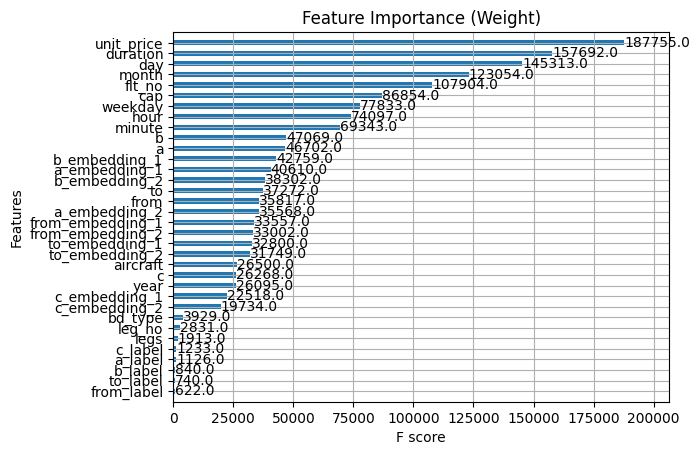

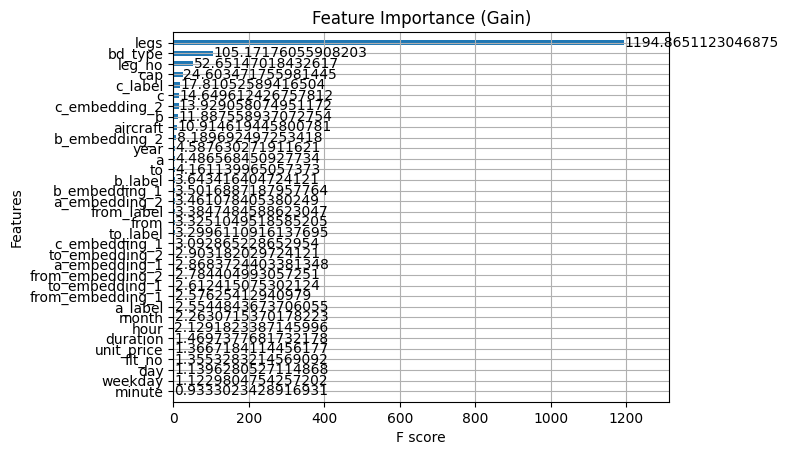

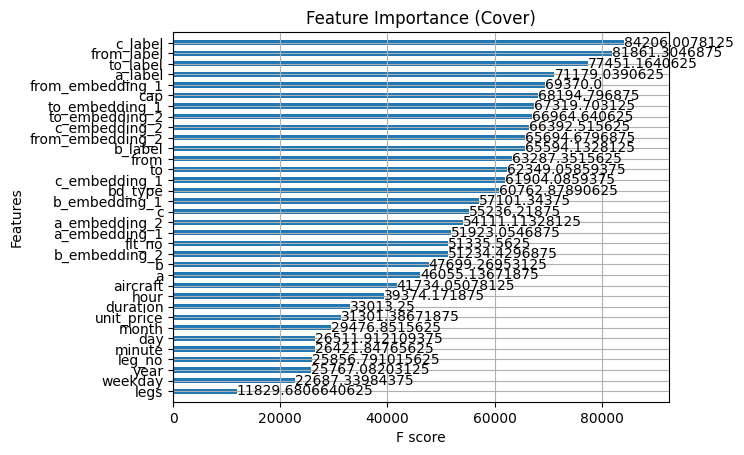

In [30]:
import xgboost as xgb
import matplotlib.pyplot as plt

# 假设 model 是训练好的 XGBoost 模型
xgb.plot_importance(model, importance_type='weight', title="Feature Importance (Weight)", height=0.5)
plt.show()

xgb.plot_importance(model, importance_type='gain', title="Feature Importance (Gain)", height=0.5)
plt.show()

xgb.plot_importance(model, importance_type='cover', title="Feature Importance (Cover)", height=0.5)
plt.show()